# LLM - Klasyfikacja tekstu

In [ ]:
!pip install -q datasets
!pip install -q torchmetrics
!pip install -q wandb
!pip install -q evaluate
!pip install -q transformers
!pip install -q bitsandbytes
!pip install -q scipy ipywidgets colorama
!pip install -q -U peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 71.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

print(f"Wersja biblioteki PyTorch: {torch.__version__}")

Wersja biblioteki PyTorch: 2.11.0+cu128


In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
SEED = 0

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

## Dataset

In [ ]:
from datasets import load_dataset

dataset = load_dataset("fancyzhx/ag_news")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [ ]:
test_dataset = dataset["test"]

split_dataset = dataset["train"].train_test_split(test_size=0.2)  # 80% train, 20% validation
train_dataset = split_dataset["train"]
val_dataset = split_dataset["test"]

print(f"Liczba próbek w zbiorze treningowym: {len(train_dataset)}")
print(f"Liczba próbek w zbiorze walidacyjnym: {len(val_dataset)}")
print(f"Liczba próbek w zbiorze testowym: {len(test_dataset)}")

Liczba próbek w zbiorze treningowym: 96000
Liczba próbek w zbiorze walidacyjnym: 24000
Liczba próbek w zbiorze testowym: 7600


In [ ]:
train_dataset[0]

{'text': 'Soccer: Real, Liverpool Advance in Champions League  LONDON (Reuters) - Former European champions Real Madrid  and Liverpool scored vastly contrasting victories to reach the  knockout round of the Champions League Wednesday.',
 'label': 1}

In [ ]:
train_dataset

Dataset({
    features: ['text', 'label'],
    num_rows: 96000
})

In [ ]:
label_names = ["World", "Sports", "Business", "Sci/Tech"]

In [ ]:
from collections import defaultdict
import random

def create_balanced_subset(dataset, n_per_class):
    random.seed(SEED)

    label_to_indices = defaultdict(list)

    for i, ex in enumerate(dataset):
        label_to_indices[ex["label"]].append(i)

    indices = []
    for label, idxs in label_to_indices.items():
        indices.extend(random.sample(idxs, n_per_class))

    random.shuffle(indices)
    return dataset.select(indices)

In [ ]:
quick_subset = create_balanced_subset(test_dataset, 250)

## Regresja logistyczna

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import pandas as pd
from tqdm import tqdm

In [ ]:
vocab_size = 10000

vectorizer = TfidfVectorizer(
    max_features=vocab_size,
    lowercase=True,
    analyzer='word',
    ngram_range=(1, 1),
    stop_words="english"
)

# Ekstrakcja cech
train_tfidf_features = vectorizer.fit_transform(train_dataset["text"])
val_tfidf_features = vectorizer.transform(val_dataset["text"])
test_tfidf_features = vectorizer.transform(test_dataset["text"])

In [ ]:
print(f"Rozmiar macierzy TF-IDF dla zbioru treningowego: {train_tfidf_features.shape}")
print(f"{train_tfidf_features.dtype=}\n")

feature_names = vectorizer.get_feature_names_out()
print(f"Liczba cech: {len(feature_names)}")
print(f"Przykładowe cechy: {np.random.choice(feature_names, 20)}\n")

Rozmiar macierzy TF-IDF dla zbioru treningowego: (96000, 10000)
train_tfidf_features.dtype=dtype('float64')

Liczba cech: 10000
Przykładowe cechy: ['winners' 'exporters' 'keeps' 'transportation' 'season' 'identification'
 'mussina' 'possible' 'finalized' 'arnold' 'developed' 'court' 'sample'
 'eagerly' 'workforce' 'america' 'ordered' 'projects' 'nominated'
 'coordinated']



In [ ]:
clf = LogisticRegression(random_state=SEED, solver='saga')
clf.fit(train_tfidf_features, train_dataset['label'])

y_pred = clf.predict(test_tfidf_features)

In [ ]:
print(classification_report(test_dataset['label'], y_pred, target_names=label_names))

              precision    recall  f1-score   support

       World       0.93      0.90      0.92      1900
      Sports       0.95      0.98      0.97      1900
    Business       0.88      0.88      0.88      1900
    Sci/Tech       0.89      0.89      0.89      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



### Dostrajanie parametrów TF-IDF

In [ ]:
test_configs = [
    {'name': 'base_10k', 'max_features': 10000, 'lowercase': True, 'analyzer': 'word', 'min_df': 1, 'max_df': 1.0, 'ngram_range': (1, 1), 'stop_words': None},
    {'name': 'bigrams_only', 'max_features': 10000, 'lowercase': True, 'analyzer': 'word', 'min_df': 1, 'max_df': 1.0, 'ngram_range': (1, 2), 'stop_words': None},
    {'name': 'frequency_filtering', 'max_features': 10000, 'lowercase': True, 'analyzer': 'word', 'min_df': 3, 'max_df': 0.8, 'ngram_range': (1, 1), 'stop_words': None},
    {'name': 'combo_word_optimal', 'max_features': None, 'lowercase': True, 'analyzer': 'word', 'min_df': 3, 'max_df': 0.9, 'ngram_range': (1, 2), 'stop_words': None},
    {'name': 'char_wb_30k', 'max_features': 30000, 'lowercase': True, 'analyzer': 'char_wb', 'min_df': 2, 'max_df': 1.0, 'ngram_range': (3, 5), 'stop_words': None},
    {'name': 'english_stopwords', 'max_features': 10000, 'lowercase': True, 'analyzer': 'word', 'min_df': 1, 'max_df': 1.0, 'ngram_range': (1, 1), 'stop_words': 'english'},
    {'name': 'word_high_min_df', 'max_features': None, 'lowercase': True, 'analyzer': 'word', 'min_df': 5, 'max_df': 0.7, 'ngram_range': (1, 2), 'stop_words': None},
    {'name': 'char_wb_heavy', 'max_features': 60000, 'lowercase': True, 'analyzer': 'char_wb', 'min_df': 2, 'max_df': 1.0, 'ngram_range': (3, 6), 'stop_words': None}
]

manual_testing_reports = []

In [ ]:
for config in test_configs:
    name = config['name']
    print(f"Processing: {name}")

    vec = TfidfVectorizer(
        max_features=config['max_features'],
        lowercase=config['lowercase'],
        analyzer=config['analyzer'],
        min_df=config['min_df'],
        max_df=config['max_df'],
        ngram_range=config['ngram_range'],
        stop_words=config['stop_words'],
        sublinear_tf=True
    )

    pipe = Pipeline([
        ('tfidf', vec),
        ('classifier', LogisticRegression(solver='saga', random_state=SEED))
    ])

    pipe.fit(train_dataset['text'], train_dataset['label'])
    preds = pipe.predict(test_dataset['text'])

    report = classification_report(test_dataset['label'], preds, output_dict=True)
    df_temp = pd.DataFrame(report).transpose().reset_index().rename(columns={'index': 'metric'})
    df_temp['config_name'] = name
    manual_testing_reports.append(df_temp)

comparison_df = pd.concat(manual_testing_reports, ignore_index=True)
accuracy_summary = comparison_df[comparison_df['metric'] == 'accuracy'][['config_name', 'precision']].sort_values(by='precision', ascending=False)
accuracy_summary.columns = ['Configuration', 'Accuracy']
display(accuracy_summary)

Processing: base_10k
Processing: bigrams_only
Processing: frequency_filtering
Processing: combo_word_optimal
Processing: char_wb_30k
Processing: english_stopwords
Processing: word_high_min_df
Processing: char_wb_heavy


,Configuration,Accuracy
46,word_high_min_df,0.916316
25,combo_word_optimal,0.916053
53,char_wb_heavy,0.913684
4,base_10k,0.913553
18,frequency_filtering,0.913553
39,english_stopwords,0.911447
11,bigrams_only,0.909211
32,char_wb_30k,0.909079


In [ ]:
metrics_summary = comparison_df[comparison_df['metric'] == 'macro avg'][['config_name', 'precision', 'recall', 'f1-score']]
metrics_summary = metrics_summary.sort_values(by='f1-score', ascending=False).reset_index(drop=True)

print("Macro-Averaged Metrics per Configuration:")
display(metrics_summary)

Macro-Averaged Metrics per Configuration:


,config_name,precision,recall,f1-score
0,word_high_min_df,0.916206,0.916316,0.916123
1,combo_word_optimal,0.915957,0.916053,0.915856
2,char_wb_heavy,0.913547,0.913684,0.913522
3,base_10k,0.913368,0.913553,0.913376
4,frequency_filtering,0.913338,0.913553,0.913350
5,english_stopwords,0.911196,0.911447,0.911237
6,bigrams_only,0.909105,0.909211,0.909070
7,char_wb_30k,0.908902,0.909079,0.908906


In [ ]:
display(comparison_df)

,metric,precision,recall,f1-score,support,config_name
0,0,0.927646,0.904211,0.915778,1900.000000,base_10k
1,1,0.953822,0.978421,0.965965,1900.000000,base_10k
2,2,0.883696,0.875789,0.879725,1900.000000,base_10k
3,3,0.888309,0.895789,0.892034,1900.000000,base_10k
4,accuracy,0.913553,0.913553,0.913553,0.913553,base_10k
5,macro avg,0.913368,0.913553,0.913376,7600.000000,base_10k
6,weighted avg,0.913368,0.913553,0.913376,7600.000000,base_10k
7,0,0.927027,0.902632,0.914667,1900.000000,bigrams_only
8,1,0.949614,0.972105,0.960728,1900.000000,bigrams_only
9,2,0.879320,0.870526,0.874901,1900.000000,bigrams_only


In [ ]:
config = test_configs[6]

vec = TfidfVectorizer(
        max_features=config['max_features'],
        lowercase=config['lowercase'],
        analyzer=config['analyzer'],
        min_df=config['min_df'],
        max_df=config['max_df'],
        ngram_range=config['ngram_range'],
        stop_words=config['stop_words'],
        sublinear_tf=True
    )

# Ekstrakcja cech
train_tfidf_features = vec.fit_transform(train_dataset["text"])
val_tfidf_features = vec.transform(val_dataset["text"])
test_tfidf_features = vec.transform(test_dataset["text"])

In [ ]:
clf = LogisticRegression(random_state=SEED, solver='saga')
clf.fit(train_tfidf_features, train_dataset['label'])

y_pred = clf.predict(test_tfidf_features)

In [ ]:
print(classification_report(test_dataset['label'], y_pred, target_names=label_names, digits=4))

              precision    recall  f1-score   support

       World     0.9328    0.9053    0.9188      1900
      Sports     0.9494    0.9774    0.9632      1900
    Business     0.8928    0.8768    0.8848      1900
    Sci/Tech     0.8899    0.9058    0.8978      1900

    accuracy                         0.9163      7600
   macro avg     0.9162    0.9163    0.9161      7600
weighted avg     0.9162    0.9163    0.9161      7600



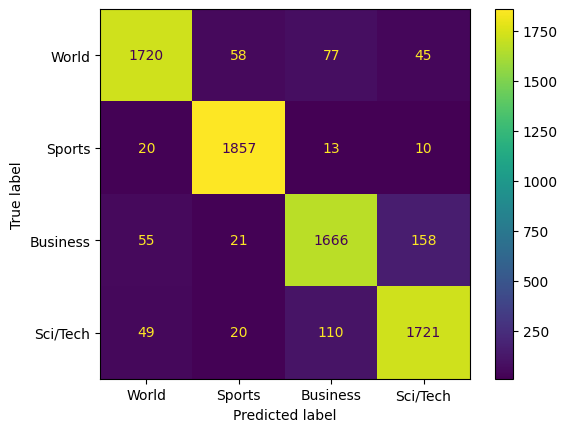

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(test_dataset['label'], y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=label_names)
disp.plot()
plt.show()

## Architektura tylko-koder

In [ ]:
import transformers

In [ ]:
import wandb

wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: drtbb07 (drtbb07-warsaw-uni) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)
tokenized_val_dataset = val_dataset.map(tokenize_function, batched=True)

print(tokenized_train_dataset)
print(tokenized_val_dataset)
print(tokenized_test_dataset)

Map:   0%|          | 0/96000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

Map:   0%|          | 0/24000 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 96000
})
Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 24000
})
Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 7600
})


In [ ]:
tokens = tokenizer.convert_ids_to_tokens(tokenized_train_dataset[0]['input_ids'])
print(tokens)

['[CLS]', 'soccer', ':', 'real', ',', 'liverpool', 'advance', 'in', 'champions', 'league', 'london', '(', 'reuters', ')', '-', 'former', 'european', 'champions', 'real', 'madrid', 'and', 'liverpool', 'scored', 'vastly', 'contrasting', 'victories', 'to', 'reach', 'the', 'knockout', 'round', 'of', 'the', 'champions', 'league', 'wednesday', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]'

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=4)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(output_dir="test_trainer", eval_strategy="steps", report_to="none",
                                  per_device_eval_batch_size=32, per_device_train_batch_size=32,
                                  logging_steps=200, fp16=False, num_train_epochs=1,
                                  remove_unused_columns=False)
print(training_args)

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=200,
eval_strategy=IntervalStrategy.STEPS,
eval_use_gather_object=False

In [ ]:
import numpy as np
from evaluate import load

accuracy_metric = load("accuracy")
f1_metric = load("f1")

labels = [e['label'] for e in train_dataset]

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc_result = accuracy_metric.compute(predictions=predictions, references=labels)
    f1_result = f1_metric.compute(predictions=predictions, references=labels, average="macro")

    return {
        "accuracy": acc_result["accuracy"],
        "macro_f1": f1_result["f1"]
    }

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_val_dataset,
    compute_metrics=compute_metrics,
)

Test przed trenowaniem

In [ ]:
print("Evaluating model performance before training...")

initial_eval_results = trainer.evaluate()

initial_predictions = trainer.predict(tokenized_test_dataset)
initial_predicted_classes = np.argmax(initial_predictions.predictions, axis=-1)

print("\nInitial Classification Report (Test Set):")
print(classification_report(initial_predictions.label_ids, initial_predicted_classes, target_names=label_names))

Evaluating model performance before training...



Initial Classification Report (Test Set):
              precision    recall  f1-score   support

       World       0.00      0.00      0.00      1900
      Sports       0.00      0.00      0.00      1900
    Business       0.26      0.92      0.40      1900
    Sci/Tech       0.35      0.15      0.21      1900

    accuracy                           0.27      7600
   macro avg       0.15      0.27      0.15      7600
weighted avg       0.15      0.27      0.15      7600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Dotrenowanie

In [ ]:
trainer.train()

Step,Training Loss,Validation Loss,Accuracy
200,0.402385,0.296503,0.902000
400,0.284800,0.252736,0.909958
600,0.268416,0.256014,0.916083
800,0.236070,0.218219,0.924250
1000,0.237217,0.213612,0.928625
1200,0.229105,0.205178,0.929125
1400,0.206103,0.204169,0.930000
1600,0.188818,0.200994,0.932708
1800,0.188792,0.193290,0.934042
2000,0.193209,0.182390,0.937750


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3000, training_loss=0.22192129135131836, metrics={'train_runtime': 2299.8864, 'train_samples_per_second': 41.741, 'train_steps_per_second': 1.304, 'total_flos': 3179330961408000.0, 'train_loss': 0.22192129135131836, 'epoch': 1.0})

In [ ]:
predictions = trainer.predict(tokenized_test_dataset)
predicted_classes = np.argmax(predictions.predictions, axis=-1)

print(classification_report(predictions.label_ids, predicted_classes, target_names=label_names))

              precision    recall  f1-score   support

       World       0.96      0.95      0.95      1900
      Sports       0.99      0.99      0.99      1900
    Business       0.92      0.91      0.91      1900
    Sci/Tech       0.91      0.93      0.92      1900

    accuracy                           0.94      7600
   macro avg       0.94      0.94      0.94      7600
weighted avg       0.94      0.94      0.94      7600



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(predictions.label_ids, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=label_names)
disp.plot()
plt.show()

### Dostrajanie parametrów

In [ ]:
import pandas as pd
import numpy as np
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import classification_report

hyperparam_configs = [
    {'name': 'baseline', 'lr': 5e-5, 'wd': 0.01, 'warmup': 0.0, 'scheduler': 'linear'},
    {'name': 'smooth_labels', 'lr': 1e-4, 'wd': 0.1, 'warmup': 0.1, 'scheduler': 'linear'},
    {'name': 'adjusted_lr_wd', 'lr': 2e-5, 'wd': 0.05, 'warmup': 0.1, 'scheduler': 'linear'},
    {'name': 'cosine_macro_opt', 'lr': 3e-5, 'wd': 0.05, 'warmup': 0.1, 'scheduler': 'cosine'}
]

distilbert_tuning_reports = []
distilbert_confusion_data = []

In [ ]:
import os

DRIVE_SAVE_PATH = '/content/drive/MyDrive/LLM_Project/DistilBERT_Tuning'
os.makedirs(DRIVE_SAVE_PATH, exist_ok=True)

Trenowanie baseline przez 3 epoki

In [ ]:
distilbert_tuning_reports = []
distilbert_confusion_data = []

In [ ]:
config = hyperparam_configs[0]
name = config['name']
print(f"\n>>> Training configuration: {name}")

tuning_model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=4)

tuning_args = TrainingArguments(
    output_dir=os.path.join(DRIVE_SAVE_PATH, name),
    eval_strategy="steps",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=config['lr'],
    weight_decay=config['wd'],
    warmup_ratio=config['warmup'],
    lr_scheduler_type=config['scheduler'],
    num_train_epochs=3,
    logging_steps=500,
    report_to="wandb",
    run_name=f"distilbert-{name}",
    seed=SEED,
    save_strategy="steps",
    save_steps=1000,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
)

wandb.init(project="distilbert-agnews-tuning", name=f"distilbert-{name}", config=config)

tuning_trainer = Trainer(
    model=tuning_model,
    args=tuning_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_val_dataset,
    compute_metrics=compute_metrics
)

tuning_trainer.train()

predictions = tuning_trainer.predict(tokenized_test_dataset)
predicted_classes = np.argmax(predictions.predictions, axis=-1)

distilbert_confusion_data.append({'config_name': name, 'y_true': predictions.label_ids, 'y_pred': predicted_classes})

report = classification_report(predictions.label_ids, predicted_classes, output_dict=True)
df_temp = pd.DataFrame(report).transpose().reset_index().rename(columns={'index': 'metric'})
df_temp['config_name'] = name
distilbert_tuning_reports.append(df_temp)

tuning_model.save_pretrained(os.path.join(DRIVE_SAVE_PATH, name, "final_model"))

wandb.finish()
print(f"--- FINISHED: {name} ---")


>>> Training configuration: baseline


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss,Accuracy
500,0.330099,0.249941,0.918875
1000,0.236936,0.234526,0.920708
1500,0.222221,0.199570,0.930625
2000,0.193717,0.192482,0.934375
2500,0.192278,0.177840,0.938250
3000,0.184237,0.170661,0.941583
3500,0.135174,0.193742,0.939958
4000,0.120866,0.191377,0.941000
4500,0.121561,0.179583,0.942333
5000,0.128088,0.177868,0.944917


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

eval/accuracy,▁▁▄▅▆▇▆▇▇████▇████
eval/loss,█▇▄▃▂▁▃▃▂▂▁▁▃▅▅▄▄▄
eval/runtime,█▁▂▁▂▂▁▂▂▃▃▂▂▁▂▂▂▂
eval/samples_per_second,▁▇▇█▇▇█▇▇▆▆▇▇█▇▇▇▇
eval/steps_per_second,▁█▇█▇▇█▇▇▆▆▇▇█▇▇▇▇
test/accuracy,▁
test/loss,▁
test/runtime,▁
test/samples_per_second,▁
test/steps_per_second,▁
+5,...


--- FINISHED: baseline ---


In [ ]:
import pandas as pd

df_tuning_reports = pd.concat(distilbert_tuning_reports, ignore_index=True)

In [ ]:
display(df_tuning_reports)

,metric,precision,recall,f1-score,support,config_name
0,0,0.967532,0.941053,0.954109,1900.000000,baseline
1,1,0.984260,0.987368,0.985812,1900.000000,baseline
2,2,0.912586,0.912105,0.912345,1900.000000,baseline
3,3,0.908577,0.931053,0.919678,1900.000000,baseline
4,accuracy,0.942895,0.942895,0.942895,0.942895,baseline
5,macro avg,0.943239,0.942895,0.942986,7600.000000,baseline
6,weighted avg,0.943239,0.942895,0.942986,7600.000000,baseline


Trenowanie smooth lables przez 3 epoki

In [ ]:
distilbert_tuning_reports = []
distilbert_confusion_data = []

In [ ]:
config = hyperparam_configs[1]
name = config['name']
print(f"\n>>> Training configuration: {name}")

tuning_model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=4)

tuning_args = TrainingArguments(
    output_dir=os.path.join(DRIVE_SAVE_PATH, name),
    eval_strategy="steps",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=config['lr'],
    weight_decay=config['wd'],
    warmup_ratio=config['warmup'],
    lr_scheduler_type=config['scheduler'],
    num_train_epochs=3,
    logging_steps=500,
    report_to="wandb",
    run_name=f"distilbert-{name}",
    seed=SEED,
    save_strategy="steps",
    save_steps=1000,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
)

wandb.init(project="distilbert-agnews-tuning", name=f"distilbert-{name}", config=config)

tuning_trainer = Trainer(
    model=tuning_model,
    args=tuning_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_val_dataset,
    compute_metrics=compute_metrics
)

tuning_trainer.train()

predictions = tuning_trainer.predict(tokenized_test_dataset)
predicted_classes = np.argmax(predictions.predictions, axis=-1)

distilbert_confusion_data.append({'config_name': name, 'y_true': predictions.label_ids, 'y_pred': predicted_classes})

report = classification_report(predictions.label_ids, predicted_classes, output_dict=True)
df_temp = pd.DataFrame(report).transpose().reset_index().rename(columns={'index': 'metric'})
df_temp['config_name'] = name
distilbert_tuning_reports.append(df_temp)

tuning_model.save_pretrained(os.path.join(DRIVE_SAVE_PATH, name, "final_model"))

wandb.finish()
print(f"--- FINISHED: {name} ---")


>>> Training configuration: smooth_labels


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss,Accuracy
500,0.510016,0.282397,0.908333
1000,0.275481,0.316845,0.909125
1500,0.268349,0.227467,0.922750
2000,0.229732,0.228863,0.921417
2500,0.215625,0.198402,0.932750
3000,0.207121,0.193595,0.934542
3500,0.158160,0.210063,0.935292
4000,0.143693,0.193957,0.939875
4500,0.145684,0.211727,0.933542
5000,0.147027,0.210553,0.936333


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

eval/accuracy,▁▁▄▄▆▆▆▇▆▇████████
eval/loss,▆█▃▃▂▂▂▂▃▃▁▁▃▃▃▃▂▂
eval/runtime,▃▂▂▂▂▁▁▂▅▅▂▂▆▆▇▂██
eval/samples_per_second,▆▇▇▇▇██▇▄▄▇▇▃▃▂▇▁▁
eval/steps_per_second,▆▇▇▇▇██▇▄▄▇▇▃▃▂▇▁▁
test/accuracy,▁
test/loss,▁
test/runtime,▁
test/samples_per_second,▁
test/steps_per_second,▁
+5,...


--- FINISHED: smooth_labels ---


In [ ]:
import pandas as pd

df_tuning_reports = pd.concat(distilbert_tuning_reports, ignore_index=True)

In [ ]:
display(df_tuning_reports)

,metric,precision,recall,f1-score,support,config_name
0,0,0.960106,0.950000,0.955026,1900.000000,smooth_labels
1,1,0.984793,0.988421,0.986604,1900.000000,smooth_labels
2,2,0.922995,0.908421,0.915650,1900.000000,smooth_labels
3,3,0.908389,0.928947,0.918553,1900.000000,smooth_labels
4,accuracy,0.943947,0.943947,0.943947,0.943947,smooth_labels
5,macro avg,0.944071,0.943947,0.943958,7600.000000,smooth_labels
6,weighted avg,0.944071,0.943947,0.943958,7600.000000,smooth_labels


Zmniejszenie learning_rate, większy weight_decay

In [ ]:
distilbert_tuning_reports = []
distilbert_confusion_data = []

In [ ]:
config = hyperparam_configs[2]
name = config['name']
print(f"\n>>> Training configuration: {name}")

tuning_model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=4)

tuning_args = TrainingArguments(
    output_dir=os.path.join(DRIVE_SAVE_PATH, name),
    eval_strategy="steps",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=config['lr'],
    weight_decay=config['wd'],
    warmup_ratio=config['warmup'],
    lr_scheduler_type=config['scheduler'],
    num_train_epochs=3,
    logging_steps=500,
    report_to="wandb",
    run_name=f"distilbert-{name}",
    seed=SEED,
    save_strategy="steps",
    save_steps=1000,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
)

wandb.init(project="distilbert-agnews-tuning", name=f"distilbert-{name}", config=config)

tuning_trainer = Trainer(
    model=tuning_model,
    args=tuning_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_val_dataset,
    compute_metrics=compute_metrics
)

tuning_trainer.train()

predictions = tuning_trainer.predict(tokenized_test_dataset)
predicted_classes = np.argmax(predictions.predictions, axis=-1)

distilbert_confusion_data.append({'config_name': name, 'y_true': predictions.label_ids, 'y_pred': predicted_classes})

report = classification_report(predictions.label_ids, predicted_classes, output_dict=True)
df_temp = pd.DataFrame(report).transpose().reset_index().rename(columns={'index': 'metric'})
df_temp['config_name'] = name
distilbert_tuning_reports.append(df_temp)

tuning_model.save_pretrained(os.path.join(DRIVE_SAVE_PATH, name, "final_model"))

wandb.finish()
print(f"--- FINISHED: {name} ---")


>>> Training configuration: adjusted_lr_wd


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss,Accuracy
500,0.738951,0.304983,0.903000
1000,0.277264,0.266132,0.911042
1500,0.242564,0.221729,0.924417
2000,0.213439,0.202726,0.930500
2500,0.204488,0.191191,0.933042
3000,0.194578,0.183316,0.936958
3500,0.159118,0.192308,0.939083
4000,0.144586,0.185843,0.939583
4500,0.144015,0.179902,0.941458
5000,0.148711,0.181969,0.942750


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

eval/accuracy,▁▂▄▅▆▇▇▇▇▇████████
eval/loss,█▆▃▂▂▁▂▂▁▁▁▁▁▂▂▂▂▁
eval/runtime,▄▄▁▃▁▁▄▄▅▆▃▃▅▅▃▆█▅
eval/samples_per_second,▅▅█▆██▅▅▄▃▆▆▄▄▆▃▁▄
eval/steps_per_second,▅▅█▆██▅▅▄▃▆▆▄▄▆▃▁▄
test/accuracy,▁
test/loss,▁
test/runtime,▁
test/samples_per_second,▁
test/steps_per_second,▁
+5,...


--- FINISHED: adjusted_lr_wd ---


In [ ]:
import pandas as pd
import os

df_tuning_reports = pd.concat(distilbert_tuning_reports, ignore_index=True)
reports_path = os.path.join(DRIVE_SAVE_PATH, 'distilbert_adjusted_reports.csv')
df_tuning_reports.to_csv(reports_path, index=False)
print(f"DistilBERT tuning reports saved to: {reports_path}")

for item in distilbert_confusion_data:
    item['y_true'] = ','.join(map(str, item['y_true']))
    item['y_pred'] = ','.join(map(str, item['y_pred']))

df_confusion_data = pd.DataFrame(distilbert_confusion_data)
confusion_path = os.path.join(DRIVE_SAVE_PATH, 'distilbert_confusion_data_adjusted.csv')
df_confusion_data.to_csv(confusion_path, index=False)
print(f"DistilBERT confusion data saved to: {confusion_path}")

DistilBERT tuning reports saved to: /content/drive/MyDrive/LLM_Project/DistilBERT_Tuning/distilbert_adjusted_reports.csv
DistilBERT confusion data saved to: /content/drive/MyDrive/LLM_Project/DistilBERT_Tuning/distilbert_confusion_data_adjusted.csv


In [ ]:
display(df_tuning_reports)

,metric,precision,recall,f1-score,support,config_name
0,0,0.966432,0.939474,0.952762,1900.000000,adjusted_lr_wd
1,1,0.985279,0.986316,0.985797,1900.000000,adjusted_lr_wd
2,2,0.924447,0.901579,0.912870,1900.000000,adjusted_lr_wd
3,3,0.897898,0.944211,0.920472,1900.000000,adjusted_lr_wd
4,accuracy,0.942895,0.942895,0.942895,0.942895,adjusted_lr_wd
5,macro avg,0.943514,0.942895,0.942975,7600.000000,adjusted_lr_wd
6,weighted avg,0.943514,0.942895,0.942975,7600.000000,adjusted_lr_wd


Zmiana schedulera na cosine, ładowanie modelu na podstawie macro f1

In [ ]:
distilbert_tuning_reports = []
distilbert_confusion_data = []

In [ ]:
config = hyperparam_configs[3]
name = config['name']
print(f"\n>>> Training configuration: {name}")

tuning_model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=4)

tuning_args = TrainingArguments(
    output_dir=os.path.join(DRIVE_SAVE_PATH, name),
    eval_strategy="steps",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=config['lr'],
    weight_decay=config['wd'],
    warmup_ratio=config['warmup'],
    lr_scheduler_type=config['scheduler'],
    num_train_epochs=3,
    logging_steps=500,
    report_to="wandb",
    run_name=f"distilbert-{name}",
    seed=SEED,
    save_strategy="steps",
    save_steps=500,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
)

wandb.init(project="distilbert-agnews-tuning", name=f"distilbert-{name}", config=config)

tuning_trainer = Trainer(
    model=tuning_model,
    args=tuning_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_val_dataset,
    compute_metrics=compute_metrics
)

tuning_trainer.train()

predictions = tuning_trainer.predict(tokenized_test_dataset)
predicted_classes = np.argmax(predictions.predictions, axis=-1)

distilbert_confusion_data.append({'config_name': name, 'y_true': predictions.label_ids, 'y_pred': predicted_classes})

report = classification_report(predictions.label_ids, predicted_classes, output_dict=True)
df_temp = pd.DataFrame(report).transpose().reset_index().rename(columns={'index': 'metric'})
df_temp['config_name'] = name
distilbert_tuning_reports.append(df_temp)

tuning_model.save_pretrained(os.path.join(DRIVE_SAVE_PATH, name, "final_model"))

wandb.finish()
print(f"--- FINISHED: {name} ---")


>>> Training configuration: cosine_macro_opt


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss,Accuracy,Macro F1
500,0.667246,0.284645,0.907625,0.907098
1000,0.269208,0.249281,0.913875,0.912919
1500,0.240183,0.225729,0.924583,0.924074
2000,0.210935,0.203104,0.930375,0.930053
2500,0.202625,0.190476,0.933458,0.933243
3000,0.194030,0.187683,0.937708,0.937467
3500,0.154099,0.198453,0.938875,0.938563
4000,0.135273,0.188612,0.940750,0.940486
4500,0.135474,0.186492,0.940792,0.940712
5000,0.141727,0.184753,0.943583,0.943459


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

eval/accuracy,▁▂▄▅▆▆▇▇▇▇████████
eval/loss,█▆▄▃▂▂▃▂▂▂▁▁▂▂▂▂▂▂
eval/macro_f1,▁▂▄▅▆▆▇▇▇▇█▇██████
eval/runtime,▂▂▁▁▂▂▁▁▁▁▁▂▁▂▄▆▆█
eval/samples_per_second,▇▇██▇▇█████▇█▇▅▃▃▁
eval/steps_per_second,▇▇██▇▇█████▇█▇▅▃▃▁
test/accuracy,▁
test/loss,▁
test/macro_f1,▁
test/runtime,▁
+7,...


--- FINISHED: cosine_macro_opt ---


In [ ]:
import pandas as pd
import os

df_tuning_reports = pd.concat(distilbert_tuning_reports, ignore_index=True)
reports_path = os.path.join(DRIVE_SAVE_PATH, 'distilbert_baseline_lowlr1_reports.csv')
df_tuning_reports.to_csv(reports_path, index=False)
print(f"DistilBERT tuning reports saved to: {reports_path}")

for item in distilbert_confusion_data:
    item['y_true'] = ','.join(map(str, item['y_true']))
    item['y_pred'] = ','.join(map(str, item['y_pred']))

df_confusion_data = pd.DataFrame(distilbert_confusion_data)
confusion_path = os.path.join(DRIVE_SAVE_PATH, 'distilbert_confusion_data_baseline_lowlr1.csv')
df_confusion_data.to_csv(confusion_path, index=False)
print(f"DistilBERT confusion data saved to: {confusion_path}")

DistilBERT tuning reports saved to: /content/drive/MyDrive/LLM_Project/DistilBERT_Tuning/distilbert_baseline_lowlr1_reports.csv
DistilBERT confusion data saved to: /content/drive/MyDrive/LLM_Project/DistilBERT_Tuning/distilbert_confusion_data_baseline_lowlr1.csv


In [ ]:
display(df_tuning_reports)

,metric,precision,recall,f1-score,support,config_name
0,0,0.960659,0.951053,0.955832,1900.000000,cosine_macro_opt
1,1,0.986301,0.985263,0.985782,1900.000000,cosine_macro_opt
2,2,0.929418,0.907895,0.918530,1900.000000,cosine_macro_opt
3,3,0.905852,0.936842,0.921087,1900.000000,cosine_macro_opt
4,accuracy,0.945263,0.945263,0.945263,0.945263,cosine_macro_opt
5,macro avg,0.945558,0.945263,0.945308,7600.000000,cosine_macro_opt
6,weighted avg,0.945558,0.945263,0.945308,7600.000000,cosine_macro_opt


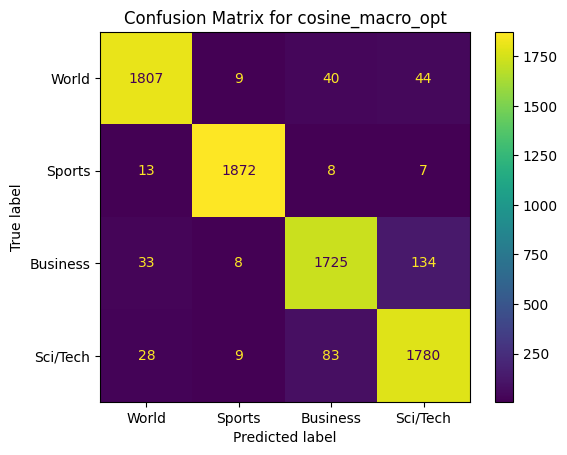

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

last_confusion_data = distilbert_confusion_data[-1]

y_true_str = last_confusion_data['y_true']
y_pred_str = last_confusion_data['y_pred']

y_true = list(map(int, y_true_str.split(',')))
y_pred = list(map(int, y_pred_str.split(',')))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=label_names)
disp.plot()
plt.title(f"Confusion Matrix for {last_confusion_data['config_name']}")
plt.show()

In [ ]:
mistake_examples = []
num_examples_to_show = 10

for i in range(len(y_true)):
    if y_true[i] != y_pred[i]:
        mistake_examples.append({
            'index': i,
            'text': test_dataset[i]['text'],
            'true_label': label_names[y_true[i]],
            'predicted_label': label_names[y_pred[i]]
        })
    if len(mistake_examples) >= num_examples_to_show:
        break

if len(mistake_examples) > 0:
    print(f"Top {len(mistake_examples)} examples where the model made mistakes:")
    for example in mistake_examples:
        print(f"\nIndex: {example['index']}")
        print(f"Text: {example['text']}")
        print(f"True Label: {example['true_label']}")
        print(f"Predicted Label: {example['predicted_label']}")
else:
    print("No mistakes found in the sampled predictions.")

Top 10 examples where the model made mistakes:

Index: 23
Text: Some People Not Eligible to Get in on Google IPO Google has billed its IPO as a way for everyday people to get in on the process, denying Wall Street the usual stranglehold it's had on IPOs. Public bidding, a minimum of just five shares, an open process with 28 underwriters - all this pointed to a new level of public participation. But this isn't the case.
True Label: Sci/Tech
Predicted Label: Business

Index: 24
Text: Rivals Try to Turn Tables on Charles Schwab By MICHAEL LIEDTKE     SAN FRANCISCO (AP) -- With its low prices and iconoclastic attitude, discount stock broker Charles Schwab Corp. (SCH) represented an annoying stone in Wall Street's wing-tipped shoes for decades...
True Label: Sci/Tech
Predicted Label: Business

Index: 36
Text: Venezuela Prepares for Chavez Recall Vote Supporters and rivals warn of possible fraud; government says Chavez's defeat could produce turmoil in world oil market.
True Label: World
Pre

## Architektura tylko-dekoder

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TextStreamer, Trainer, Seq2SeqTrainer, Seq2SeqTrainingArguments

model_name = 'speakleash/Bielik-1.5B-v3.0-Instruct'

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'left'
print(f"Rozmiar słownika: {tokenizer.vocab_size}")

config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.01k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.98M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/671 [00:00<?, ?B/s]

Rozmiar słownika: 32000


In [ ]:
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    quantization_config=quantization_config,
    device_map="auto"
)
model

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.19G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/139 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 1536, padding_idx=2)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear4bit(in_features=1536, out_features=1536, bias=True)
          (k_proj): Linear4bit(in_features=1536, out_features=256, bias=True)
          (v_proj): Linear4bit(in_features=1536, out_features=256, bias=True)
          (o_proj): Linear4bit(in_features=1536, out_features=1536, bias=True)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=1536, out_features=8960, bias=True)
          (up_proj): Linear4bit(in_features=1536, out_features=8960, bias=True)
          (down_proj): Linear4bit(in_features=8960, out_features=1536, bias=True)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((1536,), eps=1e-06)
        (post_attention_layernorm): LlamaRMSNorm((1536,), eps=1e-06)
      )
    )
    (norm): Llama

In [ ]:
import torch

def generate(model, prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=15,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    input_length = inputs.input_ids.shape[1]
    response = tokenizer.decode(output_ids[0][input_length:], skip_special_tokens=True).strip().lower()
    return response

In [ ]:
def create_test_prompt_from_data(datapoint):
  prompt = f"""
You are an article classifier.

Text: {datapoint['text']}
Choose the category for the above text. Answer only with a single digit (0, 1, 2, or 3), without any additional text.
0 = World
1 = Sports
2 = Business
3 = Sci/Tech
Label:"""

  return prompt

In [ ]:
import re

def extract_prediction_index(answer):
    match = re.search(r'[0-3]', answer)
    if match:
        return int(match.group(0))
    return None

In [ ]:
# Testowe działanie generowania.
datapoint = test_dataset[0]
label = datapoint["label"]
print(f"Treść dokumentu: {datapoint["text"]}")
print(f"Poprawna etykieta: {datapoint["label"]}")

print("\nOdpowiedź modelu:")
prompt = create_test_prompt_from_data(datapoint)
output = generate(model, prompt)
print(output)
print(f"Przewidywana etykieta: {extract_prediction_index(output[0])}")

Treść dokumentu: Fears for T N pension after talks Unions representing workers at Turner   Newall say they are 'disappointed' after talks with stricken parent firm Federal Mogul.
Poprawna etykieta: 2

Odpowiedź modelu:


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


2
Przewidywana etykieta: 2


### Few-shot learning

In [ ]:
def few_shot_prompt(item, examples):
    prompt = "Identify the category of the news text. Choices: 0=World, 1=Sports, 2=Business, 3=Sci/Tech. Respond only with the label index.\n\n"
    for ex in examples:
        prompt += f"Input: {ex['text']}\nLabel: {ex['label']}\n\n"
    prompt += f"Input: {item['text']}\nLabel:"
    return prompt

In [ ]:
def get_examples(data, n):
    np.random.seed(SEED)
    indices = []

    for label_id in range(4):
        class_indices = [i for i, x in enumerate(data) if x['label'] == label_id]
        num_samples_per_class = min(n // 4, len(class_indices))
        indices.extend(np.random.choice(class_indices, num_samples_per_class, replace=False))

    return data.select(indices)

In [ ]:
from tqdm import tqdm
from sklearn.metrics import classification_report

def evaluate_few_shot(model, test_data, train_data, n_shots=4):
    examples = get_examples(train_data, n_shots)

    y_true, y_pred = [], []

    for item in tqdm(test_data):
        prompt = few_shot_prompt(item, examples)

        response = generate(model, prompt)

        prediction = extract_prediction_index(response)

        y_true.append(item['label'])
        y_pred.append(prediction)

    mapped_y_pred = [p if p is not None and p != -1 else len(label_names) for p in y_pred]

    present_labels = sorted(list(set(y_true) | set(mapped_y_pred)))

    report_target_names = list(label_names)
    if len(label_names) in present_labels:
        report_target_names.append("Unknown")

    print("\nClassification Report:")
    print(classification_report(y_true, mapped_y_pred, labels=present_labels, target_names=report_target_names, zero_division=0))

    return y_true, y_pred

In [ ]:
prompt = few_shot_prompt(test_dataset[0], get_examples(train_dataset, 4))
print(prompt)

Identify the category of the news text. Choices: 0=World, 1=Sports, 2=Business, 3=Sci/Tech. Respond only with the label index.

Input: Iraq Expected to Dog Next U.S. President (Reuters) Reuters - The Iraq war that might have been\President Bush's defining glory may instead turn out to be his\Achilles heel -- or Democratic candidate Sen. John Kerry's\complex inheritance.
Label: 0

Input: Texans remain red hot Listening intently as the national media heaped praise on the Jacksonville Jaguars, the Texans wondered when their time would come.
Label: 1

Input: Stocks Set to Open Lower; Coke, Oil Weigh  NEW YORK (Reuters) - U.S. stocks looked to open lower on  Wednesday as concerns about Hurricane Ivan weighed on sentiment  and Coca-Cola Co. &lt;A HREF="http://www.investor.reuters.com/FullQuote.aspx?ticker=KO.N target=/stocks/quickinfo/fullquote"&gt;KO.N&lt;/A&gt; warned that earnings for the rest of  the year would lag expectations.
Label: 2

Input: The polluted planet: Alarm as global study

#### Zero-shot

In [ ]:
true_labels, predicted_labels = evaluate_few_shot(model, quick_subset, train_dataset, n_shots=0)

  0%|          | 0/1000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
100%|██████████| 1000/1000 [05:09<00:00,  3.23it/s]


Classification Report:
              precision    recall  f1-score   support

       World       0.40      0.17      0.24       250
      Sports       1.00      0.04      0.08       250
    Business       0.26      0.91      0.41       250
    Sci/Tech       0.19      0.01      0.02       250

    accuracy                           0.28      1000
   macro avg       0.46      0.28      0.19      1000
weighted avg       0.46      0.28      0.19      1000



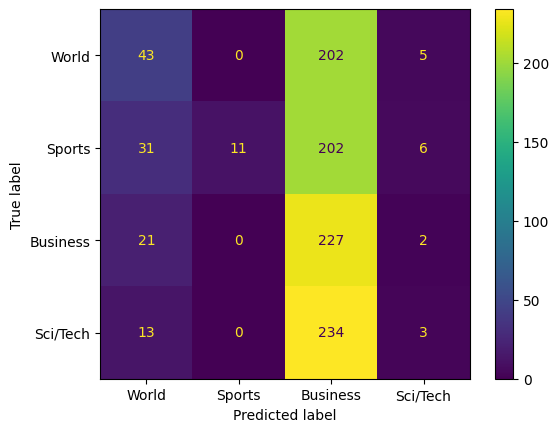

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(true_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=label_names)
disp.plot()
plt.show()

#### Few-shot

##### Base

In [ ]:
# 4-shot
true_labels, predicted_labels = evaluate_few_shot(model, quick_subset, train_dataset, n_shots=4)

  0%|          | 0/1000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
100%|██████████| 1000/1000 [25:12<00:00,  1.51s/it]


Classification Report:
              precision    recall  f1-score   support

       World       0.32      0.90      0.48       250
      Sports       1.00      0.01      0.02       250
    Business       0.58      0.45      0.51       250
    Sci/Tech       0.44      0.19      0.27       250

    accuracy                           0.39      1000
   macro avg       0.59      0.39      0.32      1000
weighted avg       0.59      0.39      0.32      1000



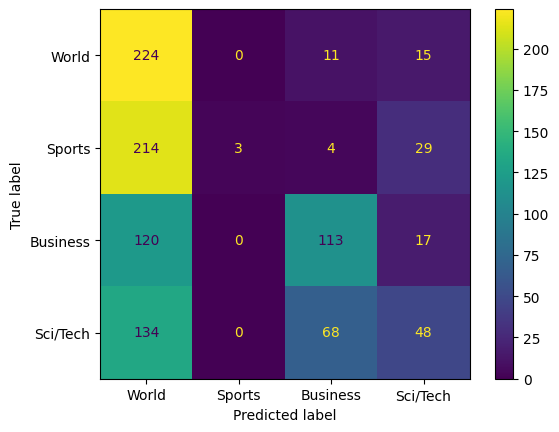

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(true_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=label_names)
disp.plot()
plt.show()

In [ ]:
# 8-shot
true_labels, predicted_labels = evaluate_few_shot(model, quick_subset, train_dataset, n_shots=8)

  0%|          | 0/1000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
100%|██████████| 1000/1000 [28:03<00:00,  1.68s/it]


Classification Report:
              precision    recall  f1-score   support

       World       0.65      0.63      0.64       250
      Sports       0.81      0.07      0.13       250
    Business       0.82      0.25      0.39       250
    Sci/Tech       0.34      0.91      0.50       250

    accuracy                           0.47      1000
   macro avg       0.66      0.46      0.41      1000
weighted avg       0.66      0.47      0.41      1000



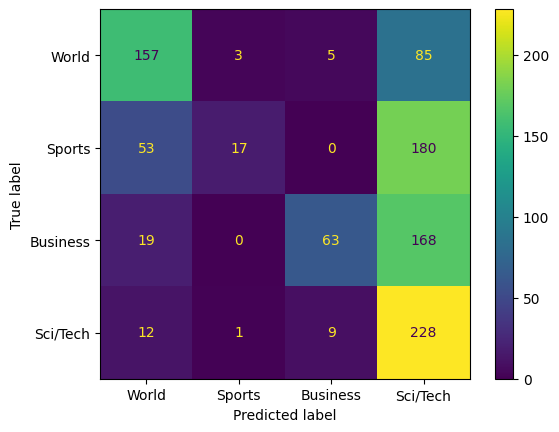

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(true_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=label_names)
disp.plot()
plt.show()

Wyniki są zawsze zbiasaowane wobec jednej z klas - może zależeć od przykładów, które są wymienione w kolejności lub ich samej treści

Dla 4-shot, bias w stronę klasy 0, bo w prompcie przykłady są w kolejności 0, 1, 2, 3, przez co model domyślnie chce wziąć 0

Dla 8-shot, bias w stronę 3, bo w prompcie jest 0, 0, 1, 1, 2, 2, 3, 3 - model chce przewidzieć znowu 3

##### Dodanie shuffle przykładów

In [ ]:
import random

def few_shot_prompt(item, examples):
    random.seed(SEED)

    prompt = "Identify the category of the news text. Choices: 0=World, 1=Sports, 2=Business, 3=Sci/Tech. Respond only with the label index.\n\n"

    if examples:
        shuffled_examples = list(examples)
        random.shuffle(shuffled_examples)

        prompt += "--- EXAMPLES ---\n\n"
        for ex in shuffled_examples:
            prompt += f"Input: {ex['text']}\nLabel: {ex['label']}\n\n"

    prompt += "--- TARGET ---\n\n"
    prompt += f"Input: {item['text']}\nLabel:"
    return prompt

In [ ]:
true_labels, predicted_labels = evaluate_few_shot(model, quick_subset, train_dataset, n_shots=4)

  0%|          | 0/1000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
100%|██████████| 1000/1000 [24:55<00:00,  1.50s/it]


Classification Report:
              precision    recall  f1-score   support

       World       0.64      0.39      0.49       250
      Sports       0.75      0.04      0.07       250
    Business       0.33      0.90      0.49       250
    Sci/Tech       0.34      0.22      0.27       250

    accuracy                           0.39      1000
   macro avg       0.52      0.39      0.33      1000
weighted avg       0.52      0.39      0.33      1000



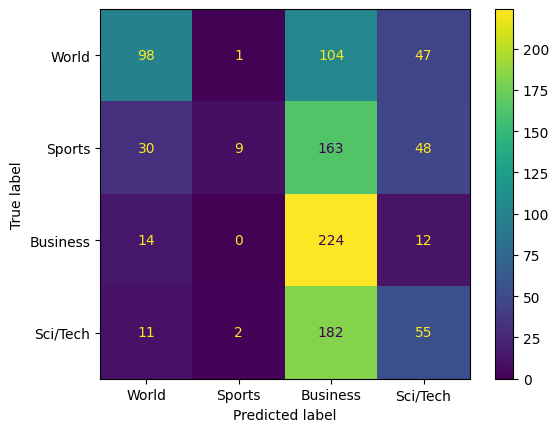

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(true_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=label_names)
disp.plot()
plt.show()

In [ ]:
true_labels, predicted_labels = evaluate_few_shot(model, quick_subset, train_dataset, n_shots=8)

  0%|          | 0/1000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
100%|██████████| 1000/1000 [27:55<00:00,  1.68s/it]


Classification Report:
              precision    recall  f1-score   support

       World       0.70      0.64      0.67       250
      Sports       0.71      0.45      0.55       250
    Business       0.54      0.68      0.60       250
    Sci/Tech       0.45      0.54      0.49       250

    accuracy                           0.58      1000
   macro avg       0.60      0.58      0.58      1000
weighted avg       0.60      0.58      0.58      1000



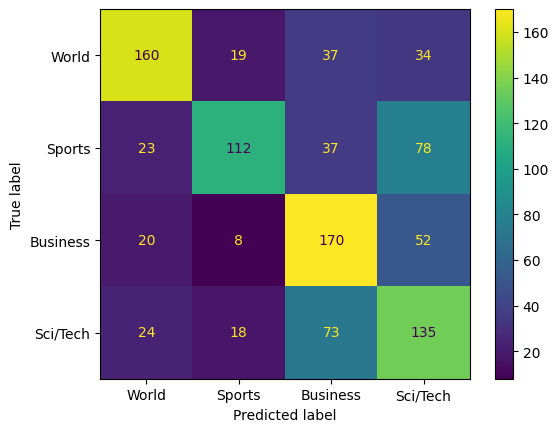

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(true_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=label_names)
disp.plot()
plt.show()

In [ ]:
true_labels, predicted_labels = evaluate_few_shot(model, quick_subset, train_dataset, n_shots=12)

  0%|          | 0/1000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
100%|██████████| 1000/1000 [30:58<00:00,  1.86s/it]


Classification Report:
              precision    recall  f1-score   support

       World       0.52      0.79      0.63       250
      Sports       0.74      0.72      0.73       250
    Business       0.68      0.38      0.49       250
    Sci/Tech       0.53      0.49      0.51       250

    accuracy                           0.60      1000
   macro avg       0.61      0.60      0.59      1000
weighted avg       0.61      0.60      0.59      1000



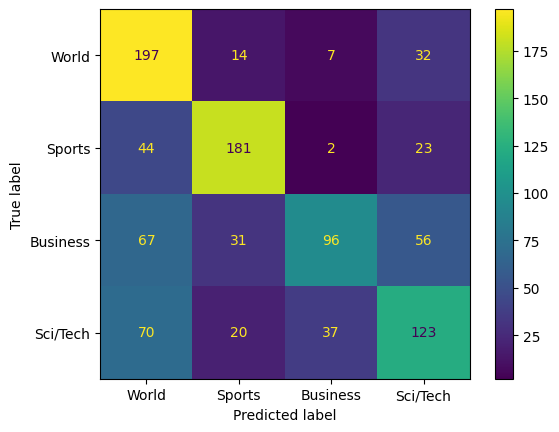

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(true_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=label_names)
disp.plot()
plt.show()

##### Zwracanie słowa odpowiadającego klasie, zamiast indeksu

In [ ]:
def few_shot_prompt_v2(item, examples, label_names):
    random.seed(SEED)

    prompt = "Identify the category of the news text. Choices: World, Sports, Business, Sci/Tech.\n\n"

    if examples:
        shuffled_examples = list(examples)
        random.shuffle(shuffled_examples)

        prompt += "--- EXAMPLES ---\n\n"
        for ex in shuffled_examples:
            prompt += f"Input: {ex['text']}\nLabel: {label_names[ex['label']]}\n\n"

    prompt += "--- TARGET ---\n\n"
    prompt += f"Input: {item['text']}\nLabel:"
    return prompt

In [ ]:
def extract_prediction_label(response, inv_map):
    clean_response = response.lower().strip()

    first_line = clean_response.split('\n')[0].strip()

    for name, label_id in inv_map.items():
        if name in first_line:
            return label_id

    return -1


In [ ]:
from tqdm import tqdm

def evaluate_few_shot_v2(model, test_data, train_data, n_shots=4):
    label_names = ["World", "Sports", "Business", "Sci/Tech"]
    inv_map = {name.lower(): i for i, name in enumerate(label_names)}

    examples = get_examples(train_data, n_shots)

    y_true, y_pred = [], []

    for item in tqdm(test_data):
        prompt = few_shot_prompt_v2(item, examples, label_names)

        response = generate(model, prompt)

        prediction = extract_prediction_label(response, inv_map)

        y_true.append(item['label'])
        y_pred.append(prediction)

    mapped_y_pred = [p if p is not None and p != -1 else len(label_names) for p in y_pred]

    present_labels = sorted(list(set(y_true) | set(mapped_y_pred)))

    report_target_names = list(label_names)
    if len(label_names) in present_labels:
        report_target_names.append("Unknown")

    print("\nClassification Report:")
    print(classification_report(y_true, mapped_y_pred, labels=present_labels, target_names=report_target_names, zero_division=0))

    return y_true, y_pred

In [ ]:
true_labels, predicted_labels = evaluate_few_shot_v2(model, quick_subset, train_dataset, n_shots=0)

  0%|          | 0/1000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
100%|██████████| 1000/1000 [22:53<00:00,  1.37s/it]


Classification Report:
              precision    recall  f1-score   support

       World       0.38      0.39      0.39       250
      Sports       1.00      0.03      0.05       250
    Business       0.00      0.00      0.00       250
    Sci/Tech       0.31      0.91      0.46       250
     Unknown       0.00      0.00      0.00         0

    accuracy                           0.33      1000
   macro avg       0.34      0.27      0.18      1000
weighted avg       0.42      0.33      0.23      1000



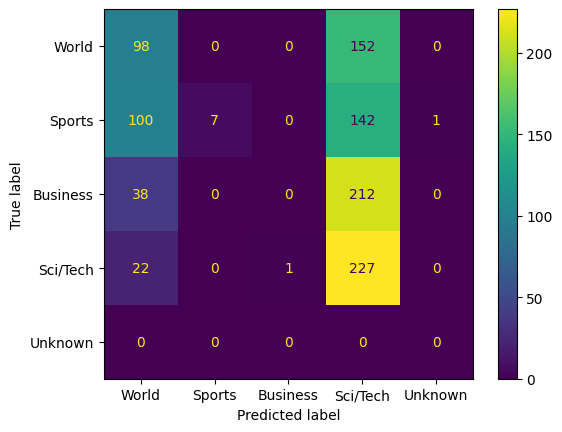

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

mapped_y_pred = [p if p != -1 else len(label_names) for p in predicted_labels]

present_labels = sorted(list(set(true_labels) | set(mapped_y_pred)))
report_target_names = list(label_names)
if len(label_names) in present_labels:
    report_target_names.append("Unknown")

cm = confusion_matrix(true_labels, mapped_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=report_target_names)
disp.plot()
plt.show()

In [ ]:
true_labels, predicted_labels = evaluate_few_shot_v2(model, quick_subset, train_dataset, n_shots=4)

  0%|          | 0/1000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
100%|██████████| 1000/1000 [23:58<00:00,  1.44s/it]


Classification Report:
              precision    recall  f1-score   support

       World       0.63      0.80      0.70       250
      Sports       0.95      0.24      0.38       250
    Business       0.49      0.87      0.62       250
    Sci/Tech       0.47      0.33      0.39       250

    accuracy                           0.56      1000
   macro avg       0.63      0.56      0.52      1000
weighted avg       0.63      0.56      0.52      1000



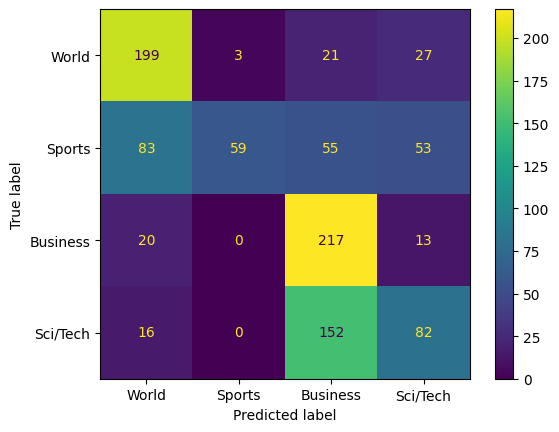

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(true_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=label_names)
disp.plot()
plt.show()

In [ ]:
true_labels, predicted_labels = evaluate_few_shot_v2(model, quick_subset, train_dataset, n_shots=8)

  0%|          | 0/1000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
100%|██████████| 1000/1000 [27:59<00:00,  1.68s/it]


Classification Report:
              precision    recall  f1-score   support

       World       0.80      0.83      0.81       250
      Sports       0.95      0.85      0.90       250
    Business       0.57      0.83      0.68       250
    Sci/Tech       0.71      0.44      0.54       250

    accuracy                           0.74      1000
   macro avg       0.76      0.74      0.73      1000
weighted avg       0.76      0.74      0.73      1000



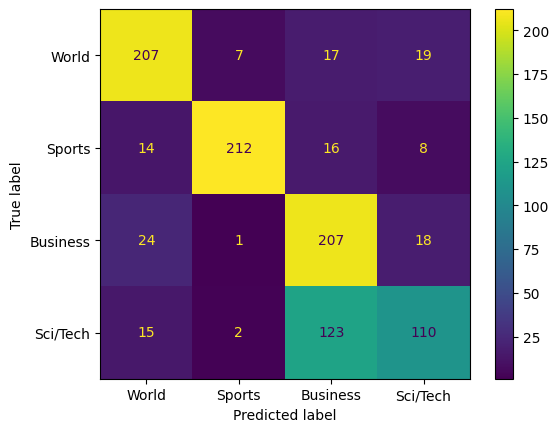

In [ ]:
cm = confusion_matrix(true_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=label_names)
disp.plot()
plt.show()

In [ ]:
true_labels, predicted_labels = evaluate_few_shot_v2(model, quick_subset, train_dataset, n_shots=12)

  0%|          | 0/1000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
100%|██████████| 1000/1000 [28:58<00:00,  1.74s/it]


Classification Report:
              precision    recall  f1-score   support

       World       0.76      0.86      0.81       250
      Sports       0.93      0.92      0.93       250
    Business       0.62      0.76      0.68       250
    Sci/Tech       0.77      0.52      0.62       250

    accuracy                           0.76      1000
   macro avg       0.77      0.76      0.76      1000
weighted avg       0.77      0.76      0.76      1000



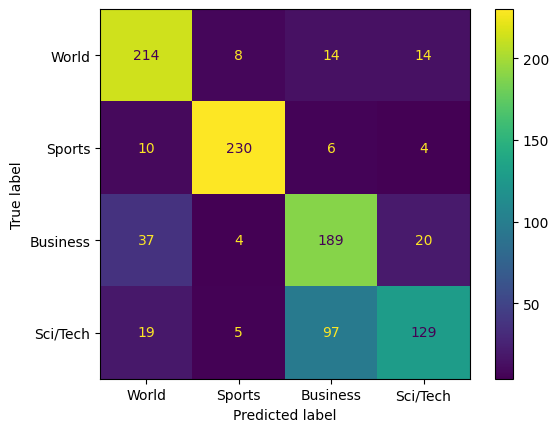

In [ ]:
cm = confusion_matrix(true_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=label_names)
disp.plot()
plt.show()

In [ ]:
true_labels, predicted_labels = evaluate_few_shot_v2(model, quick_subset, train_dataset, n_shots=16)

In [ ]:
cm = confusion_matrix(true_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=label_names)
disp.plot()
plt.show()

Full test dataset

In [ ]:
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report

class FewShotCollator:
    def __init__(self, tokenizer, train_data, n_shots, label_names):
        self.tokenizer = tokenizer
        self.label_names = label_names
        self.examples = get_examples(train_data, n_shots)

    def __call__(self, batch):
        texts = [few_shot_prompt_v2(item, self.examples, self.label_names) for item in batch]

        inputs = self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=2048,
            return_tensors="pt"
        )

        labels = torch.tensor([item['label'] for item in batch])
        return {**inputs, "labels": labels}

def fast_evaluate_few_shot(model, test_dataset, train_dataset, n_shots=4):
    label_names = ["World", "Sports", "Business", "Sci/Tech"]
    inv_map = {name.lower(): i for i, name in enumerate(label_names)}

    collator = FewShotCollator(tokenizer, train_dataset, n_shots, label_names)
    loader = DataLoader(test_dataset, batch_size=4, collate_fn=collator)

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(model.device)
            attention_mask = batch['attention_mask'].to(model.device)

            outputs = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=15,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )

            for i in range(len(outputs)):
                response = tokenizer.decode(outputs[i][input_ids.shape[1]:], skip_special_tokens=True).strip().lower()
                prediction = extract_prediction_label(response, inv_map)
                all_preds.append(prediction)

            all_labels.extend(batch['labels'].tolist())

    mapped_preds = [p if p != -1 else len(label_names) for p in all_preds]

    present_labels = sorted(list(set(all_labels) | set(mapped_preds)))

    report_target_names = list(label_names)
    if len(label_names) in present_labels:
        report_target_names.append("Unknown")

    print("\nClassification Report (Full Test Set):")
    print(classification_report(all_labels, mapped_preds, labels=present_labels, target_names=report_target_names, zero_division=0))

    return all_labels, all_preds

In [ ]:
all_labels, all_preds = fast_evaluate_few_shot(model, test_dataset, train_dataset, n_shots=4)

In [ ]:
from collections import Counter
from sklearn.metrics import classification_report

print(f"Counts for all_labels: {Counter(all_labels)}")
print(f"Counts for all_preds: {Counter(all_preds)}")

mapped_all_preds = [p if p != -1 else len(label_names) for p in all_preds]

report_labels = sorted(list(set(all_labels) | set(mapped_all_preds)))

target_names_for_report = list(label_names)
if len(label_names) in report_labels:
    target_names_for_report.append('Unknown')

print("\nClassification Report")
print(classification_report(all_labels, mapped_all_preds, labels=report_labels, target_names=target_names_for_report, zero_division=0))

Counts for all_labels: Counter({2: 1900, 3: 1900, 1: 1900, 0: 1900})
Counts for all_preds: Counter({2: 3272, 0: 2447, 3: 1407, 1: 472, -1: 2})

Classification Report
              precision    recall  f1-score   support

       World       0.61      0.78      0.68      1900
      Sports       0.96      0.24      0.38      1900
    Business       0.49      0.85      0.62      1900
    Sci/Tech       0.49      0.36      0.42      1900
     Unknown       0.00      0.00      0.00         0

    accuracy                           0.56      7600
   macro avg       0.51      0.45      0.42      7600
weighted avg       0.64      0.56      0.53      7600



In [ ]:
all_labels, all_preds = fast_evaluate_few_shot(model, test_dataset, train_dataset, n_shots=8)

Evaluating: 100%|██████████| 1900/1900 [1:14:01<00:00,  2.34s/it]


Classification Report (Full Test Set):
              precision    recall  f1-score   support

       World       0.80      0.84      0.82      1900
      Sports       0.95      0.84      0.89      1900
    Business       0.59      0.84      0.69      1900
    Sci/Tech       0.70      0.45      0.55      1900

    accuracy                           0.74      7600
   macro avg       0.76      0.74      0.74      7600
weighted avg       0.76      0.74      0.74      7600



In [ ]:
all_labels, all_preds = fast_evaluate_few_shot(model, test_dataset, train_dataset, n_shots=12)

Evaluating: 100%|██████████| 1900/1900 [1:29:13<00:00,  2.82s/it]


Classification Report (Full Test Set):
              precision    recall  f1-score   support

       World       0.76      0.87      0.81      1900
      Sports       0.93      0.91      0.92      1900
    Business       0.64      0.75      0.69      1900
    Sci/Tech       0.75      0.52      0.62      1900

    accuracy                           0.76      7600
   macro avg       0.77      0.76      0.76      7600
weighted avg       0.77      0.76      0.76      7600



### LoRA

In [ ]:
import os

DRIVE_SAVE_PATH = '/content/drive/MyDrive/LLM_Project/Bielik-1.5B-v3_Tuning'
os.makedirs(DRIVE_SAVE_PATH, exist_ok=True)

In [ ]:
import wandb

wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: drtbb07 (drtbb07-warsaw-uni) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

#### AutoModelForCausalLM

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model_name = 'speakleash/Bielik-1.5B-v3.0-Instruct'

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'left'

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=quantization_config,
    torch_dtype=torch.float16,
    device_map="auto"
)
model = prepare_model_for_kbit_training(model)

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

peft_model = get_peft_model(model, peft_config)

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

In [ ]:
from datasets import load_dataset

def train_prompt(examples):
    output_text = []
    for text, label in zip(examples["text"], examples["label"]):
        prompt = (
            f"Identify the category of the news text. Choices: World, Sports, Business, Sci/Tech.\n\n"
            f"Input: {text}\n"
            f"Label: {label_names[label]}"
        )
        output_text.append(prompt)
    return {"text": output_text}

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=256,
        padding=False
    )

columns_to_remove = train_dataset.column_names

tokenized_train = train_dataset.map(train_prompt, batched=True).map(tokenize_function, batched=True, remove_columns=columns_to_remove)
tokenized_val = val_dataset.map(train_prompt, batched=True).map(tokenize_function, batched=True, remove_columns=columns_to_remove)

Map:   0%|          | 0/96000 [00:00<?, ? examples/s]

Map:   0%|          | 0/96000 [00:00<?, ? examples/s]

Map:   0%|          | 0/24000 [00:00<?, ? examples/s]

Map:   0%|          | 0/24000 [00:00<?, ? examples/s]

In [ ]:
trainer_val_subset = tokenized_val.select(range(64))

In [ ]:
from transformers import DataCollatorForLanguageModeling
import os

wandb.init(project="bielik-agnews-tuning", name="bielik-generative-optimized")

final_output_dir = os.path.join(DRIVE_SAVE_PATH, "bielik-agnews-qlora")

trainer = transformers.Trainer(
    model=peft_model,
    train_dataset=tokenized_train,
    eval_dataset=trainer_val_subset,
    args=transformers.TrainingArguments(
        output_dir=final_output_dir,
        max_steps=300,
        per_device_train_batch_size=8,
        gradient_accumulation_steps=4,
        per_device_eval_batch_size=32,
        learning_rate=5e-5,
        optim="paged_adamw_8bit",
        fp16=True,
        bf16=False,
        logging_strategy="steps",
        logging_steps=20,
        eval_strategy="steps",
        eval_steps=100,
        save_strategy="steps",
        save_steps=100,
        report_to="wandb"
    ),
    data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
)

peft_model.config.use_cache = False
trainer.train()

trainer.save_model(os.path.join(final_output_dir, "final_model"))
tokenizer.save_pretrained(os.path.join(final_output_dir, "final_model"))

peft_model.config.use_cache = True
wandb.finish()

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss
100,1.295741,1.262460
200,1.273077,1.238595
300,1.269634,1.231231


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


eval/loss,█▃▁
eval/runtime,▃█▁
eval/samples_per_second,▆▁█
eval/steps_per_second,▆▁█
train/epoch,▁▂▂▃▃▃▃▄▅▅▆▆▆▆▇▇███
train/global_step,▁▁▂▃▃▃▃▄▅▅▅▅▆▇▇▇███
train/grad_norm,▇▂▁▃▂▂▆▂▁█▃▅▃▄▂
train/learning_rate,█▇▇▇▆▅▅▅▄▃▃▂▂▁▁
train/loss,█▆▄▁▃▂▃▂▁▁▂▁▂▃▁
eval/loss,1.23123
eval/runtime,4.9179


Loading model

In [ ]:
from peft import PeftModel
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

model_name = 'speakleash/Bielik-1.5B-v3.0-Instruct'
final_output_dir = '/content/drive/MyDrive/LLM_Project/Bielik-1.5B-v3_Tuning/bielik-agnews-qlora-2/final_model'

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=quantization_config,
    torch_dtype=torch.float16,
    device_map="auto"
)

peft_model = PeftModel.from_pretrained(base_model, final_output_dir)

tokenizer = AutoTokenizer.from_pretrained(final_output_dir)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'left'


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

In [ ]:
def test_prompt(item):
    prompt = (
        f"Identify the category of the news text. Choices: World, Sports, Business, Sci/Tech.\n\n"
        f"Input: {item['text']}\n"
        f"Label:"
    )

    return prompt

In [ ]:
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report

class LoraCollator:
    def __init__(self, tokenizer, label_names):
        self.tokenizer = tokenizer
        self.label_names = label_names

    def __call__(self, batch):
        texts = [test_prompt(item) for item in batch]

        inputs = self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=1024,
            return_tensors="pt"
        )

        labels = torch.tensor([item['label'] for item in batch])
        return {**inputs, "labels": labels}

def fast_evaluate_lora(model, test_dataset):
    label_names = ["World", "Sports", "Business", "Sci/Tech"]
    inv_map = {name.lower(): i for i, name in enumerate(label_names)}

    collator = LoraCollator(tokenizer, label_names)
    loader = DataLoader(test_dataset, batch_size=4, collate_fn=collator)

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(model.device)
            attention_mask = batch['attention_mask'].to(model.device)

            outputs = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=15,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )

            for i in range(len(outputs)):
                response = tokenizer.decode(outputs[i][input_ids.shape[1]:], skip_special_tokens=True).strip().lower()
                prediction = extract_prediction_label(response, inv_map)
                all_preds.append(prediction)

            all_labels.extend(batch['labels'].tolist())

    mapped_preds = [p if p != -1 else len(label_names) for p in all_preds]

    present_labels = sorted(list(set(all_labels) | set(mapped_preds)))

    report_target_names = list(label_names)
    if len(label_names) in present_labels:
        report_target_names.append("Unknown")

    print("\nClassification Report:")
    print(classification_report(all_labels, mapped_preds, labels=present_labels, target_names=report_target_names, zero_division=0))

    return all_labels, all_preds

In [ ]:
from tqdm import tqdm

def evaluate_lora(model, test_data):
    label_names = ["World", "Sports", "Business", "Sci/Tech"]
    inv_map = {name.lower(): i for i, name in enumerate(label_names)}

    y_true, y_pred = [], []

    for item in tqdm(test_data):
        prompt = test_prompt(item)

        response = generate(model, prompt)

        prediction = extract_prediction_label(response, inv_map)

        y_true.append(item['label'])
        y_pred.append(prediction)

    target_names = label_names + (['Unknown'] if -1 in y_pred else [])
    print(classification_report(y_true, y_pred, target_names=target_names))
    return y_true, y_pred

Subset

In [ ]:
y_true, y_pred = evaluate_lora(peft_model, quick_subset)

100%|██████████| 1000/1000 [39:42<00:00,  2.38s/it]

              precision    recall  f1-score   support

       World       0.90      0.89      0.90       250
      Sports       0.96      0.99      0.97       250
    Business       0.84      0.84      0.84       250
    Sci/Tech       0.90      0.88      0.89       250

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000



Full test dataset

In [ ]:
y_true, y_pred = fast_evaluate_lora(peft_model, test_dataset)

Evaluating: 100%|██████████| 1900/1900 [1:29:02<00:00,  2.81s/it]


Classification Report:
              precision    recall  f1-score   support

       World       0.92      0.89      0.91      1900
      Sports       0.96      0.99      0.97      1900
    Business       0.86      0.87      0.86      1900
    Sci/Tech       0.89      0.87      0.88      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



Training for 600 steps

In [ ]:
import transformers
from transformers import DataCollatorForLanguageModeling
import os

wandb.init(project="bielik-agnews-tuning", name="bielik-generative-optimized")

final_output_dir = os.path.join(DRIVE_SAVE_PATH, "bielik-agnews-qlora-2")

trainer = transformers.Trainer(
    model=peft_model,
    train_dataset=tokenized_train,
    eval_dataset=trainer_val_subset,
    args=transformers.TrainingArguments(
        output_dir=final_output_dir,
        max_steps=600,
        per_device_train_batch_size=4,
        gradient_accumulation_steps=8,
        per_device_eval_batch_size=8,
        learning_rate=5e-5,
        optim="paged_adamw_8bit",
        fp16=True,
        bf16=False,
        logging_strategy="steps",
        logging_steps=20,
        eval_strategy="steps",
        eval_steps=100,
        save_strategy="steps",
        save_steps=100,
        report_to="wandb"
    ),
    data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
)

peft_model.config.use_cache = False
trainer.train()

trainer.save_model(os.path.join(final_output_dir, "final_model"))
tokenizer.save_pretrained(os.path.join(final_output_dir, "final_model"))

peft_model.config.use_cache = True
wandb.finish()

train/epoch,▁
train/global_step,▁
train/grad_norm,▁
train/learning_rate,▁
train/loss,▁
train/epoch,0.00667
train/global_step,20
train/grad_norm,0.98348
train/learning_rate,5e-05
train/loss,1.34784


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss
100,1.279889,1.247566
200,1.260796,1.224056
300,1.251673,1.213482
400,1.240572,1.202536
500,1.225164,1.200143
600,1.225425,1.196621


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

eval/loss,█▅▃▂▁▁
eval/runtime,█▅▄▁▁▁
eval/samples_per_second,▁▄▅███
eval/steps_per_second,▁▄▅███
train/epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
train/global_step,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
train/grad_norm,▅▃▃▂▃▁▄▂▁█▃▅▄▆▂▆▄▃▃▃▅▄▅▃▂▄▄▃▄▃
train/learning_rate,███▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▁▁▁
train/loss,▄██▄▆▅▆▅▄▄▅▃▄▆▃▅▂▂▃▃▃▄▂▂▁▃▂▁▂▁
eval/loss,1.19662
eval/runtime,3.5462


In [ ]:
y_true, y_pred = fast_evaluate_lora(peft_model, test_dataset)

Evaluating: 100%|██████████| 1900/1900 [1:23:51<00:00,  2.65s/it]


Classification Report:
              precision    recall  f1-score   support

       World       0.94      0.89      0.91      1900
      Sports       0.96      0.99      0.97      1900
    Business       0.87      0.90      0.89      1900
    Sci/Tech       0.90      0.89      0.90      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



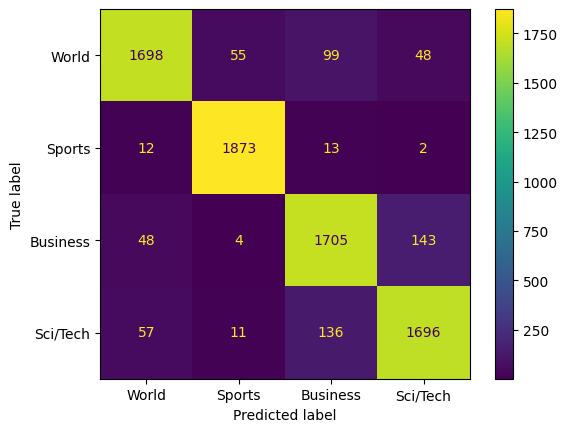

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=label_names)
disp.plot()
plt.show()